# Modes of a Ring Resonator

In Tutorial/Basics/Modes of a Ring Resonator, the modes of a ring resonator were computed by performing a 2d simulation. This example involves simulating the same structure while exploiting the fact that the system has continuous rotational symmetry, by performing the simulation in cylindrical coordinates. 

As always, the starting point is to import the meep and other library modules:

In [1]:
import meep as mp
import argparse


The parameters of the problem are defined with exactly the same values as in the 2d simulation:

In [2]:
n = 3.4     # index of waveguide
w = 1       # width of waveguide
r = 1       # inner radius of ring
pad = 4     # padding between waveguide and edge of PML
dpml = 2    # thickness of PML

The dimensions and size of the computational cell are defined:

In [3]:
sr = r + w + pad + dpml         # radial size (cell is from 0 to sr)
dimensions = mp.CYLINDRICAL
cell = mp.Vector3(sr, 0, 0)

The key thing is to set the dimensions parameter to **CYLINDRICAL**. This means that all vectors represent (r
,ϕ
,z
) coordinates instead of (x
,y
,z
). The computational cell in the r
 direction is of size **sr = r + w + pad + dpml**, and runs from 0 to sr (by default) rather than from **-sr/2** to **sr/2** as it would for any other dimension. Note that the z
 size is 0 because it is in 2d. The ϕ
 size is also 0, corresponding to the continuous rotational symmetry. A finite ϕ
 size might correspond to discrete rotational symmetry, but this is not currently supported.

In particular, in systems with continuous rotational symmetry, by an analogue of Bloch's theorem, the angular dependence of the fields can always be chosen in the form exp(imϕ)
 for some integer m
. Meep uses this fact to treat the angular dependence analytically, with m
 given by the input variable m which is set to a command-line argument that is 3 by default.

The geometry is now specified by a single **Block** object — remember that this is a block in cylindrical coordinates, so that it really specifies an annular ring:

In [4]:
geometry = [mp.Block(center=mp.Vector3(r + (w / 2)),
                     size=mp.Vector3(w, 1e20, 1e20),
                     material=mp.Medium(index=n))]

pml_layers = [mp.PML(dpml)]
resolution = 10

PMLs are on "all" sides. The z
 direction has no thickness and therefore it is automatically periodic with no PML. PML is also omitted from the boundary at r
=0 which is handled by the analytical reflection symmetry.

The remaining inputs are almost exactly the same as in the previous 2d simulation. A single Gaussian point source is added in the z
 direction to excite Ez
-polarized modes, with some center frequency and width:

In [8]:
fcen    = 0.15  # pulse center frequency
df      = 0.1   # pulse width (in frequency)
m       = 3     # phi (angular) dependence of the fields given by exp(i m phi)

sources = [mp.Source(src=mp.GaussianSource(fcen, fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(r + 0.1))]

Note that this isn't really a point source, however, because of the **cylindrical symmetry**—it is really a **ring source** with a $\phi$ dependence of $\exp(im\phi)$.

Finally, as before, the fields are time-stepped until the source has turned off, plus 200 additional time units. During this time, `Harminv` is used to analyze the $E_z$ field at a given point to extract the **frequencies and decay rates** of the modes.

In [9]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    boundary_layers=pml_layers,
                    resolution=resolution,
                    sources=sources,
                    dimensions=dimensions,
                    m=m)

show the setup geometry

/opt/anaconda3/envs/meep/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/meep/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


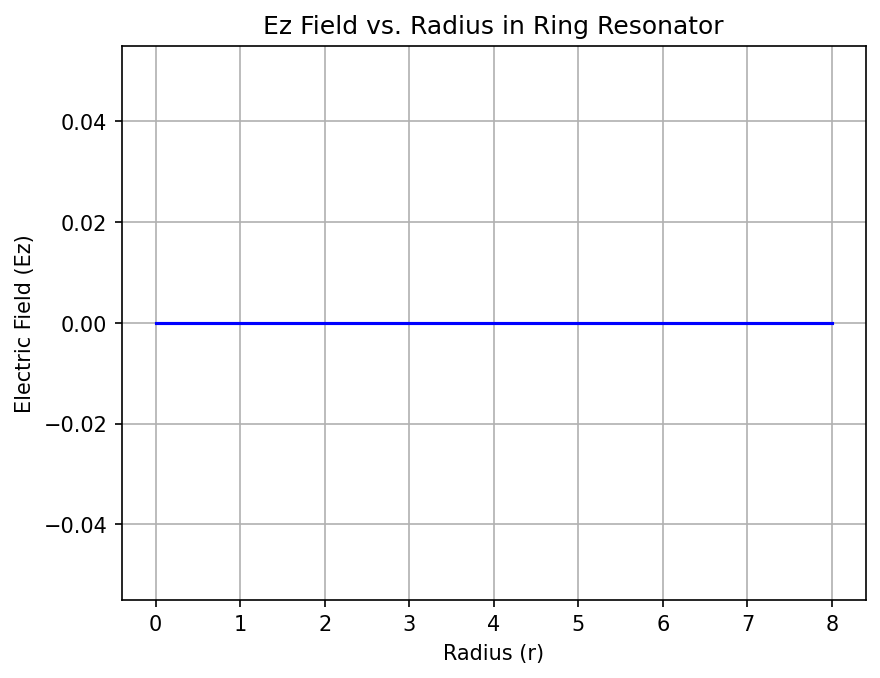

In [13]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# After the simulation runs, get the field data
sim.init_sim() # This is still good practice
ez_data = sim.get_efield_z()

# FIX: Manually generate the radial coordinates
num_points = int(sr * resolution)
r_coords = np.linspace(0, sr, num_points)



plt.figure(dpi=150)
plt.plot(r_coords, ez_data, 'b-')
plt.xlabel("Radius (r)")
plt.ylabel("Electric Field (Ez)")
plt.title("Ez Field vs. Radius in Ring Resonator")
plt.grid(True)
plt.show()